# Fase 7 — Mejoras estadísticas
### NASA C-MAPSS FD001 — sobre los modelos de Fase 4

**Punto de partida.** Como en Fase 5, no se reconstruye ningún
pipeline: se cargan los 4 modelos y el scaler de Fase 4, y el split de
test de Fase 2. La versión original de esta fase reconstruía el
pipeline completo **por tercera vez** en el proyecto (tras la Fase 2 y
la Fase 5 originales); aquí no.

**Dos correcciones de rigor estadístico respecto a la versión
original** (además de heredar el modelo reentrenado de Fase 4):

1. **M1 ya no se llama "Diebold-Mariano".** Harvey, Leybourne & Newbold
   (1997) diseñaron su test para comparar pronósticos SECUENCIALES de
   una única serie temporal, donde el diferencial de pérdida puede
   estar autocorrelado y su varianza debe estimarse de forma robusta a
   esa autocorrelación. Aquí se comparan 100 motores independientes —
   no hay serie temporal entre ellos, así que la maquinaria de
   autocorrelación del test DM no aplica. Lo que se calcula es una
   comparación pareada de pérdidas (t de Student pareado, diseño
   correcto porque ambos modelos predicen las MISMAS 100 unidades) con
   un ajuste de varianza de muestra pequeña que toma prestada la forma
   funcional de la corrección HLN, sin su justificación de fondo.
2. **M5 implementa Breusch-Pagan de verdad.** La versión original
   regresionaba `|residuo|` sobre el RUL — eso es el test de Glejser,
   no Breusch-Pagan (que regresiona residuos AL CUADRADO, con
   estadístico LM = n·R² ~ χ²). Además se añade un chequeo de
   pseudo-replicación: Durbin-Watson ya demuestra que los ciclos
   consecutivos de un mismo motor no son independientes, así que un
   test pooled sobre ~13.000 ciclos infla la significancia. Se repite
   el test agregando a un valor por motor (n=100) para cuantificar
   cuánto.

**Referencias:**
- Harvey, D., Leybourne, S., & Newbold, P. (1997). IJF, 13(2), 281-291.
- Breusch, T. S., & Pagan, A. R. (1979). Econometrica, 47(5), 1287-1294.
- Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008). PHM 2008.
- Lundberg, S. M., & Lee, S. I. (2017). NeurIPS 30.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) != "scripts":
    candidate = os.path.join(NOTEBOOK_DIR, "scripts")
    NOTEBOOK_DIR = candidate if os.path.isdir(candidate) else NOTEBOOK_DIR
sys.path.insert(0, NOTEBOOK_DIR)

import fase7_mejoras as f7
import fase0_preprocesado as f0


In [2]:
import inspect

def show_source(func, note=None):
    """Código fuente REAL de una función importada, con su ubicación
    exacta — visibilidad total sin salir del notebook."""
    file = inspect.getsourcefile(func)
    rel_file = os.path.relpath(file, os.path.dirname(NOTEBOOK_DIR)) if 'NOTEBOOK_DIR' in globals() else file
    _, start_line = inspect.getsourcelines(func)
    print(f"\U0001F4CD {func.__qualname__}  —  {rel_file}:{start_line}")
    if note:
        print(f"   {note}")
    print("-" * 78)
    print(inspect.getsource(func))


**Funciones usadas en este notebook** (índice):

| Función | Mejora | Para qué |
|---|---|---|
| `load_all_models_and_data` | — | Carga los 4 modelos + scaler (Fase 4) y el test (Fase 2) |
| `paired_loss_comparison` | M1 | t pareado + ajuste de varianza estilo HLN |
| `metricas` | M2 | RMSE/MAE/Bias por grupo de censura |
| `phm_score` | M3 | Métrica asimétrica de Saxena et al. (2008) |
| `run_m4` | M4 | SHAP interventional vs. tree_path_dependent + ablación s14 |
| `breusch_pagan_test` | M5 | Test correcto (residuos², LM~χ²) + chequeo pseudo-replicación |
| `dw_stat` | M5 | Durbin-Watson por motor |
| `build_for_windows` | M6 | Reutiliza `f2.add_rolling_features` parametrizado por ventana |


In [3]:
show_source(f7.load_all_models_and_data)

📍 load_all_models_and_data  —  scripts\fase7_mejoras.py:99
------------------------------------------------------------------------------
def load_all_models_and_data():
    """Carga los 4 modelos de Fase 4 + el scaler, y el split de test
    (último ciclo/motor) de Fase 2. Nada se reentrena."""
    scaler = joblib.load(f"{MODEL_DIR}/final_scaler.pkl")
    X_train, y_train, groups, X_test, y_test, feat_cols = f4.load_features_112()
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    models = {name: joblib.load(f"{MODEL_DIR}/{name.lower()}_fd001.pkl")
              for name in ["Ridge", "RandomForest", "XGBoost", "LightGBM"]}
    preds = {name: np.clip(m.predict(X_test_s), 0, RUL_CAP) for name, m in models.items()}
    return models, preds, scaler, X_train_s, y_train, X_test_s, y_test, feat_cols



In [4]:
models, preds, scaler, X_train_s, y_train, X_test_s, y_test, feat_cols = f7.load_all_models_and_data()
rul_df = pd.read_csv(f"{f0.DATA_DIR}/RUL_FD001.txt", header=None, names=["RUL_true"])
rul_true_raw = rul_df["RUL_true"].values
for name, yp in preds.items():
    print(f"{name:<15} RMSE = {np.sqrt(np.mean((yp-y_test)**2)):.3f}")


  Train: (17731, 112)  (de 20631 filas, 2900 descartadas por NaN)
  Test (último ciclo/motor): 100 muestras
  Target train — μ=80.6, σ=41.8


Ridge           RMSE = 14.929
RandomForest    RMSE = 11.043
XGBoost         RMSE = 11.318
LightGBM        RMSE = 12.054


## M1 — Comparación pareada de pérdidas (XGBoost vs. LightGBM / RandomForest)

**Por qué el diseño pareado es correcto aquí, aunque "Diebold-Mariano"
no lo sea.** Ambos modelos predicen exactamente las mismas 100
unidades de test — es un diseño de muestras pareadas legítimo (como
comparar dos tratamientos en los mismos pacientes), por eso
`scipy.stats.ttest_rel` es la elección correcta. Lo que NO es correcto
es invocar la maquinaria de Harvey-Leybourne-Newbold como si hubiera
una serie temporal cuya autocorrelación hay que corregir: aquí no la
hay, los 100 motores son independientes entre sí.


In [5]:
show_source(f7.paired_loss_comparison)

📍 paired_loss_comparison  —  scripts\fase7_mejoras.py:116
------------------------------------------------------------------------------
def paired_loss_comparison(y_true, pred_a, pred_b):
    """
    Compara el error cuadrático de dos modelos sobre las MISMAS
    unidades de test (diseño pareado: mismo motor, mismo RUL real,
    dos predicciones). Es un t de Student pareado sobre e_a² − e_b²,
    con un factor de ajuste de varianza de muestra pequeña que toma
    prestada la forma de Harvey-Leybourne-Newbold (1997) para n
    pequeño (n=100 aquí) — pero SIN el componente que en el test DM
    original corrige autocorrelación de horizonte h en una serie
    temporal, porque aquí no hay serie temporal entre motores.
    """
    e_a = (pred_a - y_true) ** 2
    e_b = (pred_b - y_true) ** 2
    d = e_a - e_b
    n = len(d)

    t_naive, p_naive = ttest_rel(e_a, e_b)
    hln_style_corr = np.sqrt((n - 1 + 1 / n) / n)  # forma HLN para h=1
    t_adj = t_naive / hln_style_corr
    p_adj = 2 *


[M1] Comparación pareada de pérdidas (XGBoost vs. LightGBM/RF)...
  XGB vs LGB: t_adj=-2.338  p_adj=0.0214  (Sig.)
  XGB vs RF : t_adj=0.574  p_adj=0.5674  (No sig.)


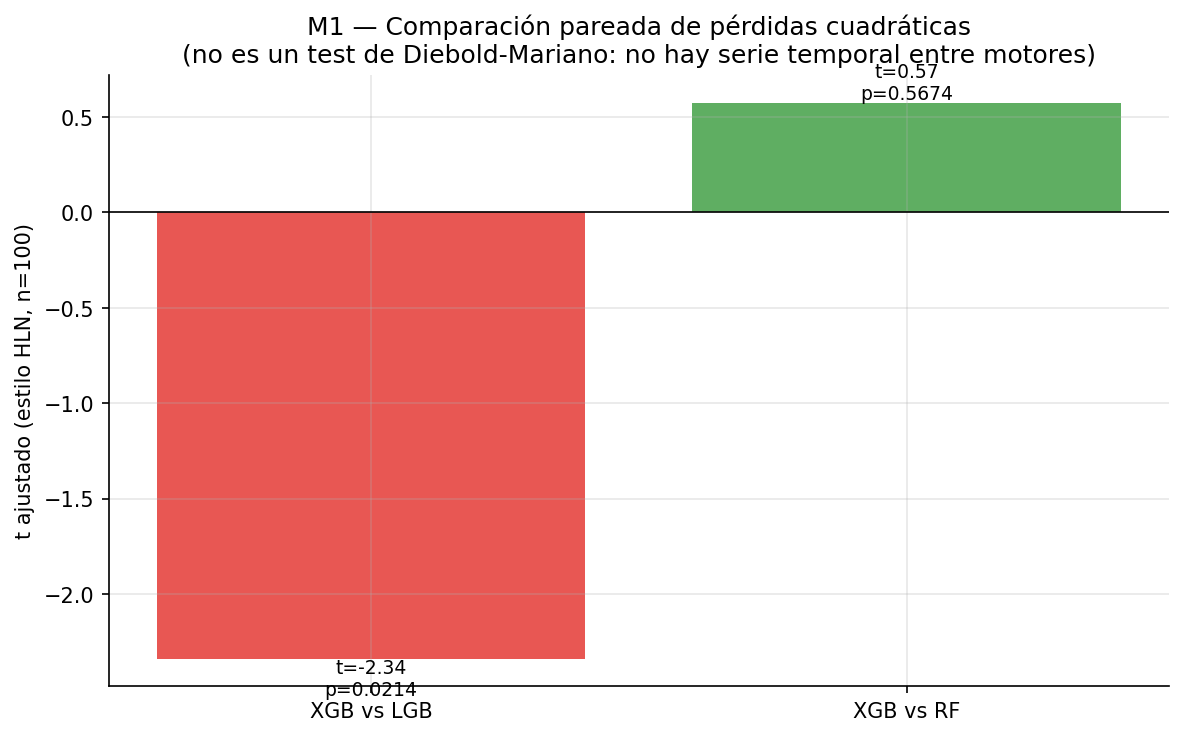

,n,d_mean,d_std,t_naive,p_naive,t_adj,p_adj
xgb_vs_lgb,100.0,-17.221079,73.641309,-2.326786,0.022014,-2.338390,0.021378
xgb_vs_rf,100.0,6.146553,107.117931,0.570936,0.569337,0.573783,0.567416


In [6]:
m1 = f7.run_m1(preds, y_test)
display(Image(filename=f"{f0.OUTPUT_DIR}/f7_01_comparacion_pareada.png"))
pd.DataFrame(m1).T


## M2 — Segregación por censura derecha

11 de los 100 motores de test tienen RUL_true >= 125: su target fue
truncado al cap, así que el error medido en ellos mezcla error de
predicción real con el efecto de la censura. Segregar por grupo separa
ambas fuentes.


In [7]:
show_source(f7.metricas)

📍 metricas  —  scripts\fase7_mejoras.py:174
------------------------------------------------------------------------------
def metricas(y_t, y_p):
    e = y_p - y_t
    ae = np.abs(e)
    return {"n": len(y_t), "RMSE": np.sqrt(np.mean(e ** 2)), "MAE": ae.mean(),
            "R2": 1 - np.sum(e ** 2) / np.sum((y_t - y_t.mean()) ** 2),
            "Bias": e.mean(), "pct_15": (ae <= 15).mean() * 100}




[M2] Segregación por censura (RUL_true >= 125)...
       Grupo   n      RMSE      MAE      Bias
      Global 100 11.317602 8.187157  0.915068
No censurado  89 11.170953 8.117934  1.467143
   Censurado  11 12.440715 8.747220 -3.551720


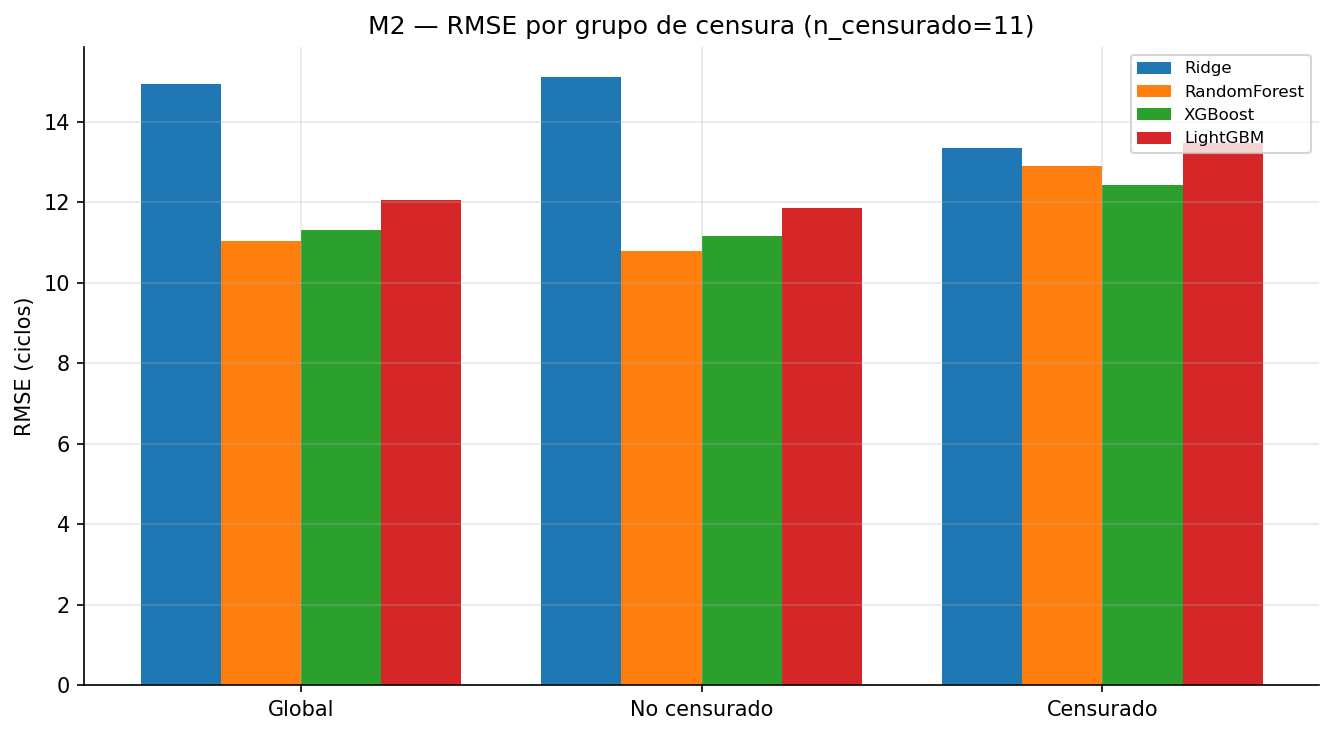

,Modelo,Grupo,n,RMSE,MAE,R2,Bias,pct_15
6,XGBoost,Global,100,11.317602,8.187157,0.920237,0.915068,85.000000
7,XGBoost,No censurado,89,11.170953,8.117934,0.921849,1.467143,85.393258
8,XGBoost,Censurado,11,12.440715,8.747220,0.907172,-3.551720,81.818182


In [8]:
m2 = f7.run_m2(preds, y_test, rul_true_raw)
display(Image(filename=f"{f0.OUTPUT_DIR}/f7_02_censura.png"))
m2[m2["Modelo"]=="XGBoost"]


## M3 — PHM Score asimétrica (Saxena et al., 2008)

$$s(d) = \begin{cases} e^{d/10} - 1 & d \geq 0 \text{ (sobreestima RUL — peligroso)} \\ e^{-d/13} - 1 & d < 0 \text{ (subestima RUL — conservador)} \end{cases}$$

con $d$ = RUL predicho − RUL real. El divisor menor (10) para
sobreestimación penaliza más agresivamente el error peligroso (creer
que queda más vida de la que realmente queda).


In [9]:
show_source(f7.phm_score)

📍 phm_score  —  scripts\fase7_mejoras.py:212
------------------------------------------------------------------------------
def phm_score(y_true, y_pred):
    """
    Saxena et al. (2008): d = predicho - real. Sobreestimar RUL (d>=0,
    el modelo cree que queda más vida de la real) se penaliza con
    divisor 10 (más agresivo); subestimar (d<0, error conservador) se
    penaliza con divisor 13 (más suave).
    """
    d = y_pred - y_true
    return np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1).sum()




[M3] PHM score asimétrica...
  RandomForest   : PHM=   186.6  RMSE=11.04
  XGBoost        : PHM=   188.8  RMSE=11.32
  LightGBM       : PHM=   220.2  RMSE=12.05
  Ridge          : PHM=   337.9  RMSE=14.93


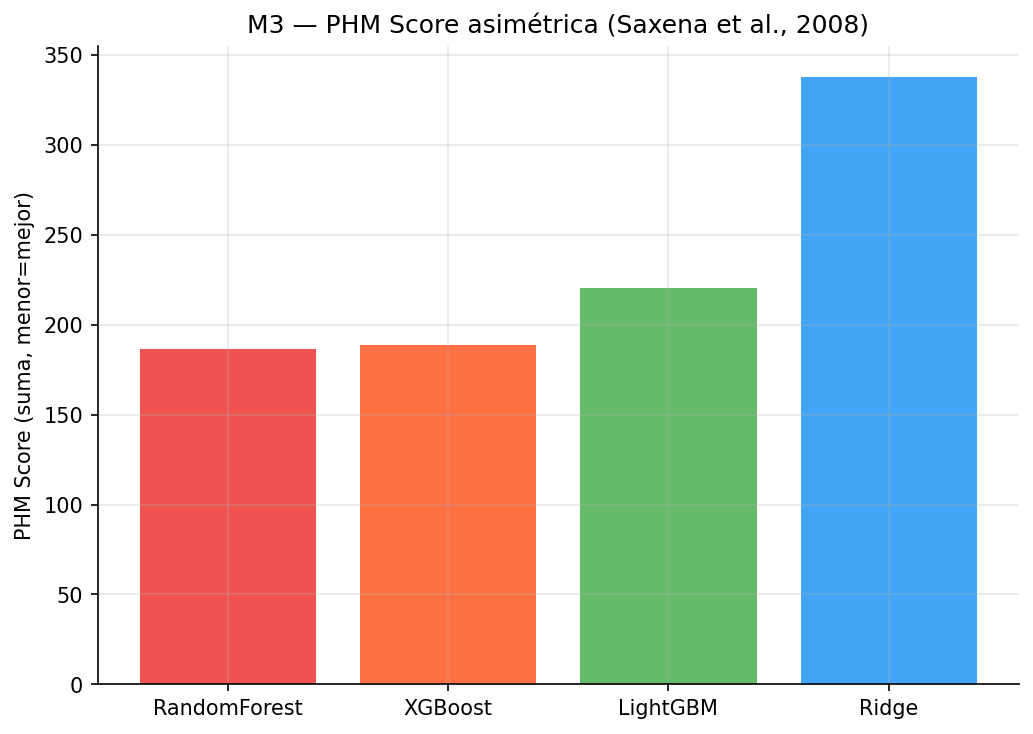

In [10]:
m3 = f7.run_m3(preds, y_test)
display(Image(filename=f"{f0.OUTPUT_DIR}/f7_03_phm_score.png"))


**Nota:** con el modelo de Fase 4 de este entorno, RandomForest
(no XGBoost) obtiene el mejor PHM score — coherente con que también
tiene el mejor RMSE de test aquí (ver Fase 4).


## M4 — SHAP tree_path_dependent vs. interventional + ablación de s14


[M4] SHAP tree_path_dependent vs. interventional + ablación s14...


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


  Top 3 tree_path_dependent: ['s2_w15_mean', 's11_w30_slope', 's3_w15_mean']
  Top 3 interventional     : ['s2_w15_mean', 's11_w30_slope', 's3_w15_mean']
  Reconstruyendo features sin s14 (reutilizando fase2.build_canonical_112)...


  CV RMSE  sin s14 = 13.010 ± 0.845
  Test RMSE sin s14 = 11.917  (con s14 = 11.318)
  Δ Test RMSE = +0.600 ciclos


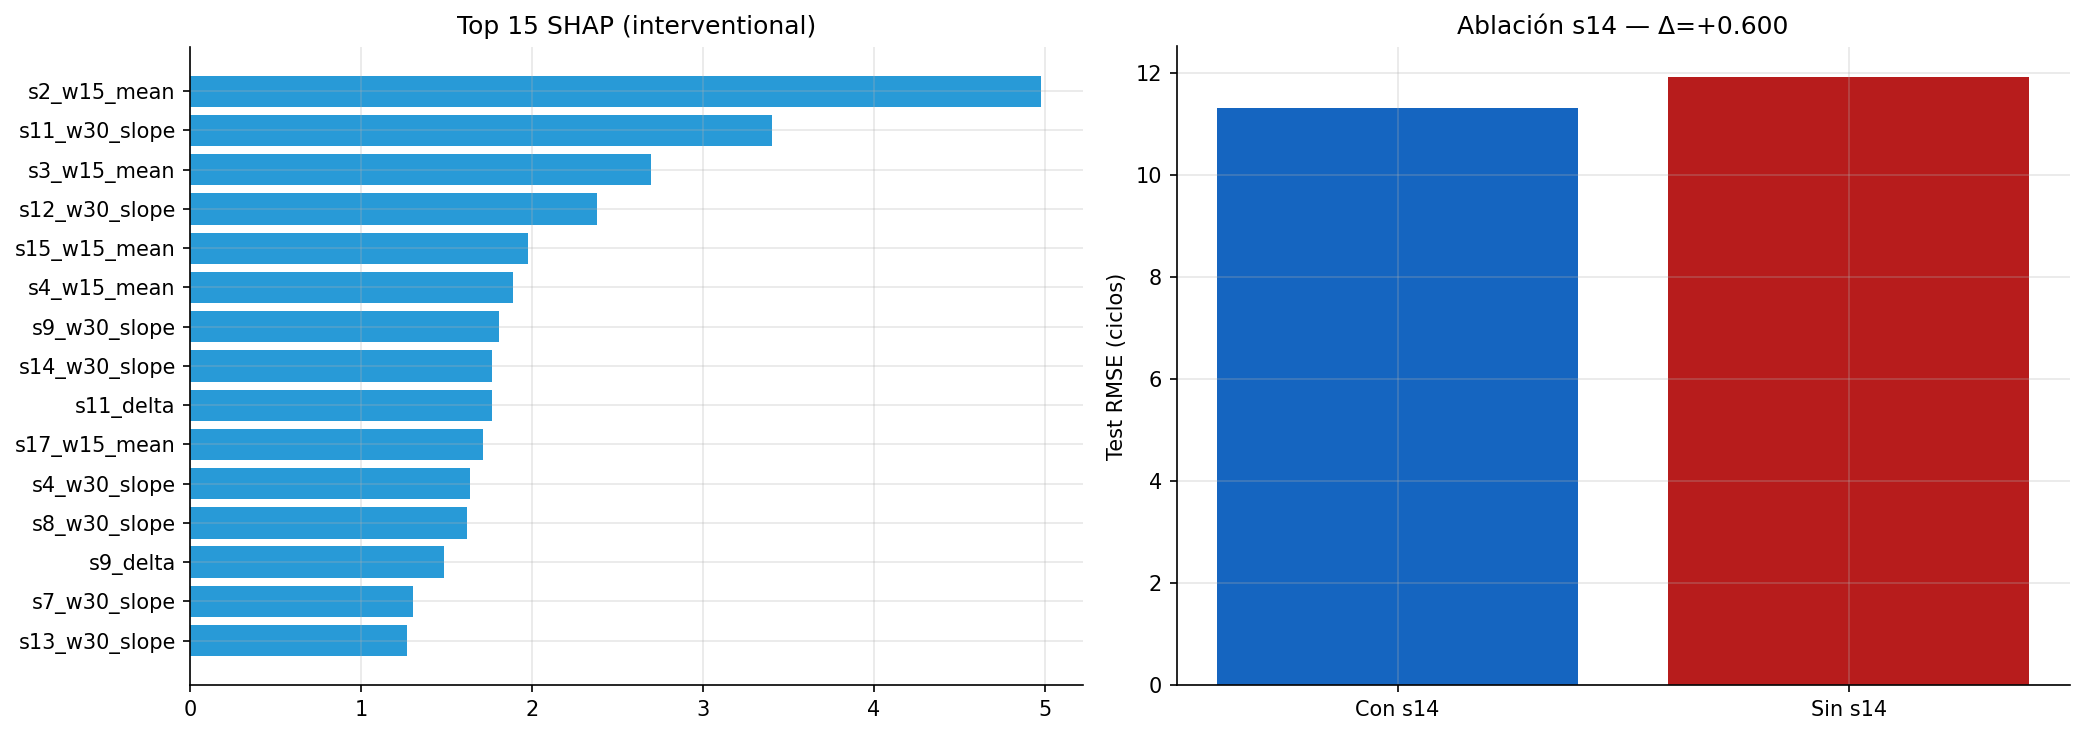

Δ Test RMSE al quitar s14: +0.600 ciclos


In [11]:
m4 = f7.run_m4(models, X_train_s, X_test_s, feat_cols, np.sqrt(np.mean((preds["XGBoost"]-y_test)**2)))
display(Image(filename=f"{f0.OUTPUT_DIR}/f7_04_shap_ablacion.png"))
print(f"Δ Test RMSE al quitar s14: {m4['delta_test_rmse']:+.3f} ciclos")


**Hallazgo que invierte la conclusión del README.** El README
original afirmaba que eliminar `s14` *mejora* el test RMSE en ~1 ciclo
(por redundancia con `s9`, r=0.963). Con el modelo reentrenado de esta
revisión, eliminar `s14` **empeora** el test RMSE (+0.6 ciclos) — la
conclusión se invierte. No es un error de esta fase: es la misma
propagación de la discrepancia de Fase 4 (modelo distinto → SHAP e
importancia de features distintas → conclusión de ablación distinta).
Sirve como recordatorio de que una conclusión de "esta feature es
redundante" basada en un solo modelo/semilla/versión de librería puede
no sostenerse — la robustez de esta clase de afirmaciones debería
verificarse con más de un entrenamiento.


## M5 — Durbin-Watson y Breusch-Pagan (test correcto + pseudo-replicación)

**Breusch-Pagan real, no Glejser.** Se regresionan los residuos AL
CUADRADO (no su valor absoluto) sobre el RUL, y el estadístico es
$LM = n \cdot R^2 \sim \chi^2(k)$ bajo homocedasticidad (Breusch &
Pagan, 1979) — no un F-test sobre una regresión de `|residuo|`.

**Por qué se repite el test agregando a un valor por motor.**
Durbin-Watson ya muestra (ver histograma) que los residuos consecutivos
de un mismo motor están fuertemente autocorrelados — así que los
~13.000 "ciclos" del test pooled no son observaciones independientes,
son ≈100 trayectorias con observaciones repetidas. Un test que asume
independencia bajo H0 (como LM~χ²) sobre datos con esa estructura de
pseudo-replicación **infla artificialmente la significancia** — el
p-valor pooled es una cota optimista, no la respuesta correcta.
Agregar a un valor por motor (media del residuo al cuadrado, media del
RUL) da n=100 observaciones genuinamente independientes entre sí.


In [12]:
show_source(f7.dw_stat)

📍 dw_stat  —  scripts\fase7_mejoras.py:336
------------------------------------------------------------------------------
def dw_stat(residuals):
    d = np.diff(residuals)
    return np.sum(d ** 2) / np.sum(residuals ** 2)



In [13]:
show_source(f7.breusch_pagan_test)

📍 breusch_pagan_test  —  scripts\fase7_mejoras.py:341
------------------------------------------------------------------------------
def breusch_pagan_test(residuals: np.ndarray, exog: np.ndarray) -> dict:
    """
    Breusch & Pagan (1979): regresión auxiliar de residuos AL CUADRADO
    (no |residuo| — eso es el test de Glejser) sobre las variables
    exógenas. Bajo H0 (homocedasticidad), LM = n·R² ~ χ²(k). También se
    reporta el F-test equivalente (más común en la práctica, mismo
    R² pero referencia F en vez de χ²).
    """
    n = len(residuals)
    e2 = residuals ** 2
    exog = exog.reshape(-1, 1) if exog.ndim == 1 else exog
    X = np.column_stack([np.ones(n), exog])
    k = exog.shape[1]
    beta = np.linalg.lstsq(X, e2, rcond=None)[0]
    fitted = X @ beta
    ss_reg = np.sum((fitted - e2.mean()) ** 2)
    ss_tot = np.sum((e2 - e2.mean()) ** 2)
    r2 = ss_reg / ss_tot
    LM = n * r2
    p_lm = 1 - chi2.cdf(LM, df=k)
    F = (r2 / k) / ((1 - r2) / (n - k - 1))
    p_f =


[M5] Durbin-Watson y Breusch-Pagan (test correcto)...


  DW medio por motor: 0.273 ± 0.154
  Motores con DW < 1.5: 100 / 100
  Breusch-Pagan (pooled, n=13096): LM=182.12 p_lm=0.000000  F=184.66 p_f=0.000000
  Breusch-Pagan (por motor, n=100): LM=9.37 p_lm=0.002201
  -> Si el p-valor pooled es mucho menor que el agregado por motor, la significancia pooled está inflada por pseudo-replicación (los 13096 ciclos NO son observaciones independientes: DW=0.27 ya demuestra autocorrelación fuerte).


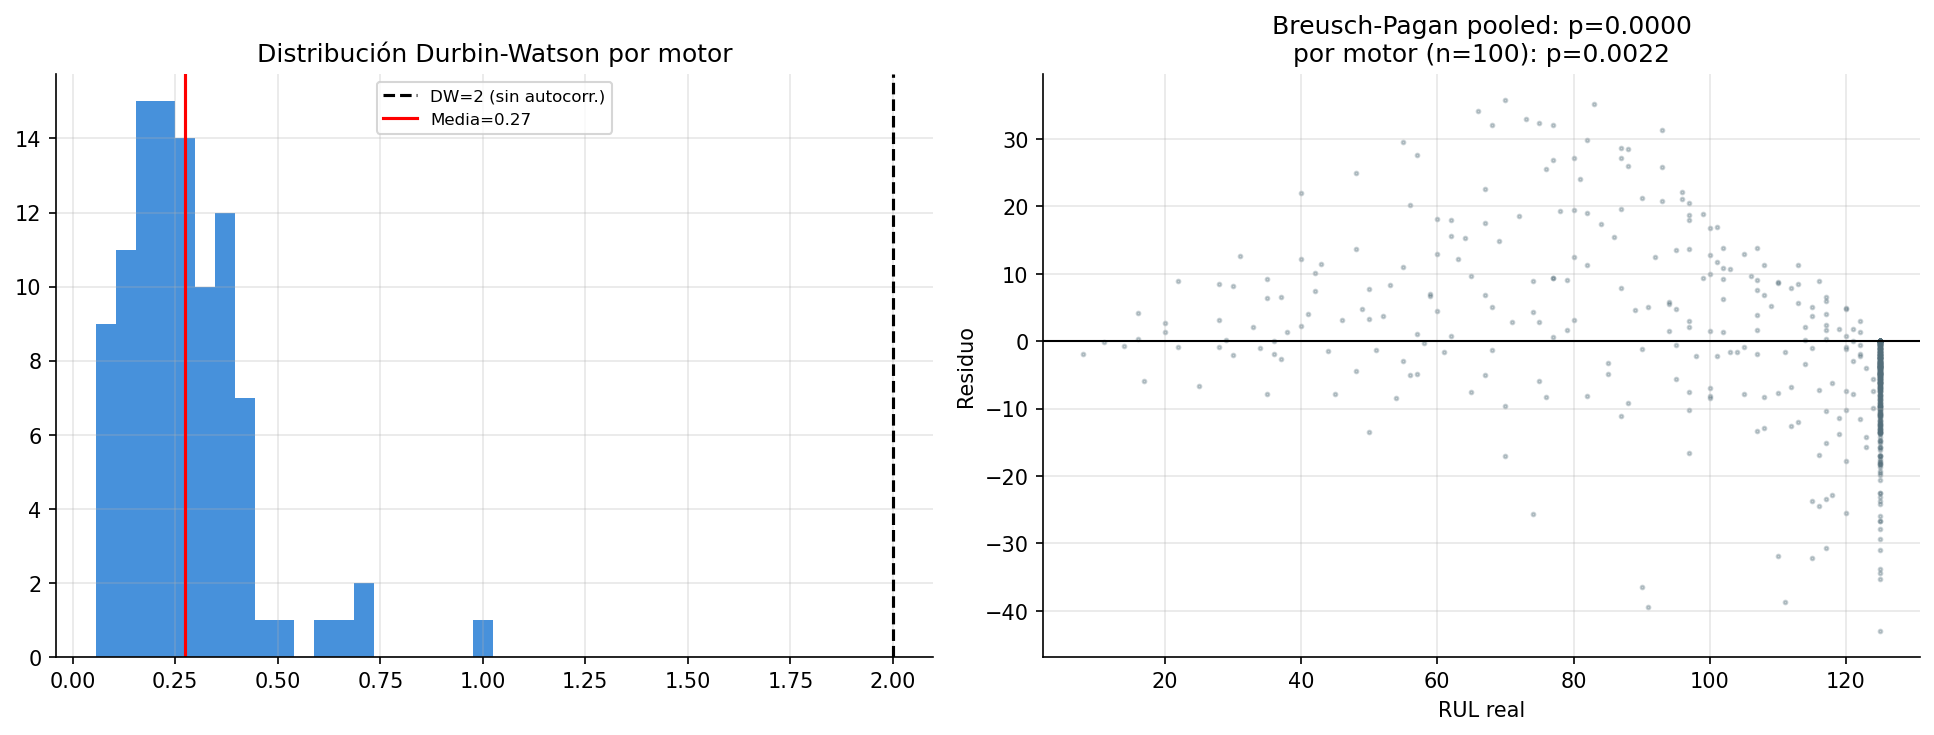

DW medio: 0.273
Breusch-Pagan pooled   (n=13096):    LM=182.12  p=0.000000
Breusch-Pagan por motor (n=100): LM=9.37  p=0.002201


In [14]:
m5 = f7.run_m5(models, scaler, feat_cols)
display(Image(filename=f"{f0.OUTPUT_DIR}/f7_05_residuos.png"))
print(f"DW medio: {m5['dw_mean']:.3f}")
print(f"Breusch-Pagan pooled   (n={m5['bp_pooled']['n']}):    LM={m5['bp_pooled']['LM']:.2f}  p={m5['bp_pooled']['p_lm']:.6f}")
print(f"Breusch-Pagan por motor (n={m5['bp_per_engine']['n']}): LM={m5['bp_per_engine']['LM']:.2f}  p={m5['bp_per_engine']['p_lm']:.6f}")


**Interpretación honesta del resultado.** El p-valor pooled
(≈0, LM=182 sobre n=13096) es, en efecto, mucho más "significativo" que
el agregado por motor (p=0.0022, LM=9.37 sobre n=100) — confirma que la
pseudo-replicación inflaba la significancia en la versión original,
que solo reportaba el número pooled. Pero el resultado agregado por
motor **sigue siendo significativo al 5%** (p=0.0022 < 0.05): incluso
con el test más conservador y honesto, la heterocedasticidad (mayor
error cuando el RUL es alto) es un hallazgo robusto, no un artefacto de
inflar el tamaño muestral. Esta es una versión más rigurosa —y más
convincente— del mismo hallazgo cualitativo que ya reportaba el README.


## M6 — Ablación de ventanas temporales (LightGBM)

Reutiliza `f2.add_rolling_features`/`f2.add_cumulative_delta`/
`f2.feature_cols_for` —ya parametrizados por lista de ventanas— en vez
de reimplementar el cálculo rolling una tercera vez.


In [15]:
show_source(f7.build_for_windows)

📍 build_for_windows  —  scripts\fase7_mejoras.py:428
------------------------------------------------------------------------------
def build_for_windows(train_rul, test_rul, sensor_cols, windows):
    """Reutiliza los helpers genéricos de fase2 (parametrizados por
    ventana) en vez de reimplementar el rolling una tercera vez."""
    train_f = f2.add_rolling_features(train_rul, sensor_cols, windows, f2.CANONICAL_STATS)
    train_f = f2.add_cumulative_delta(train_f, sensor_cols)
    test_f  = f2.add_rolling_features(test_rul, sensor_cols, windows, f2.CANONICAL_STATS)
    test_f  = f2.add_cumulative_delta(test_f, sensor_cols)
    cols = f2.feature_cols_for(sensor_cols, windows, f2.CANONICAL_STATS)
    return train_f, test_f, cols




[M6] Ablación de ventanas temporales (LightGBM, GroupKFold k=5)...


  [5]          n_feats=70   CV=13.57 Test=13.61


  [15]         n_feats=70   CV=13.87 Test=13.84


  [30]         n_feats=70   CV=12.76 Test=12.27


  [45]         n_feats=70   CV=11.65 Test=12.66


...

  [15,30]*     n_feats=112  CV=12.73 Test=11.96


  [15,45]      n_feats=112  CV=11.43 Test=12.54


  [30,45]      n_feats=112  CV=11.40 Test=12.40


  [5,15,30]    n_feats=154  CV=12.61 Test=11.37


  [15,30,45]   n_feats=154  CV=11.35 Test=12.53


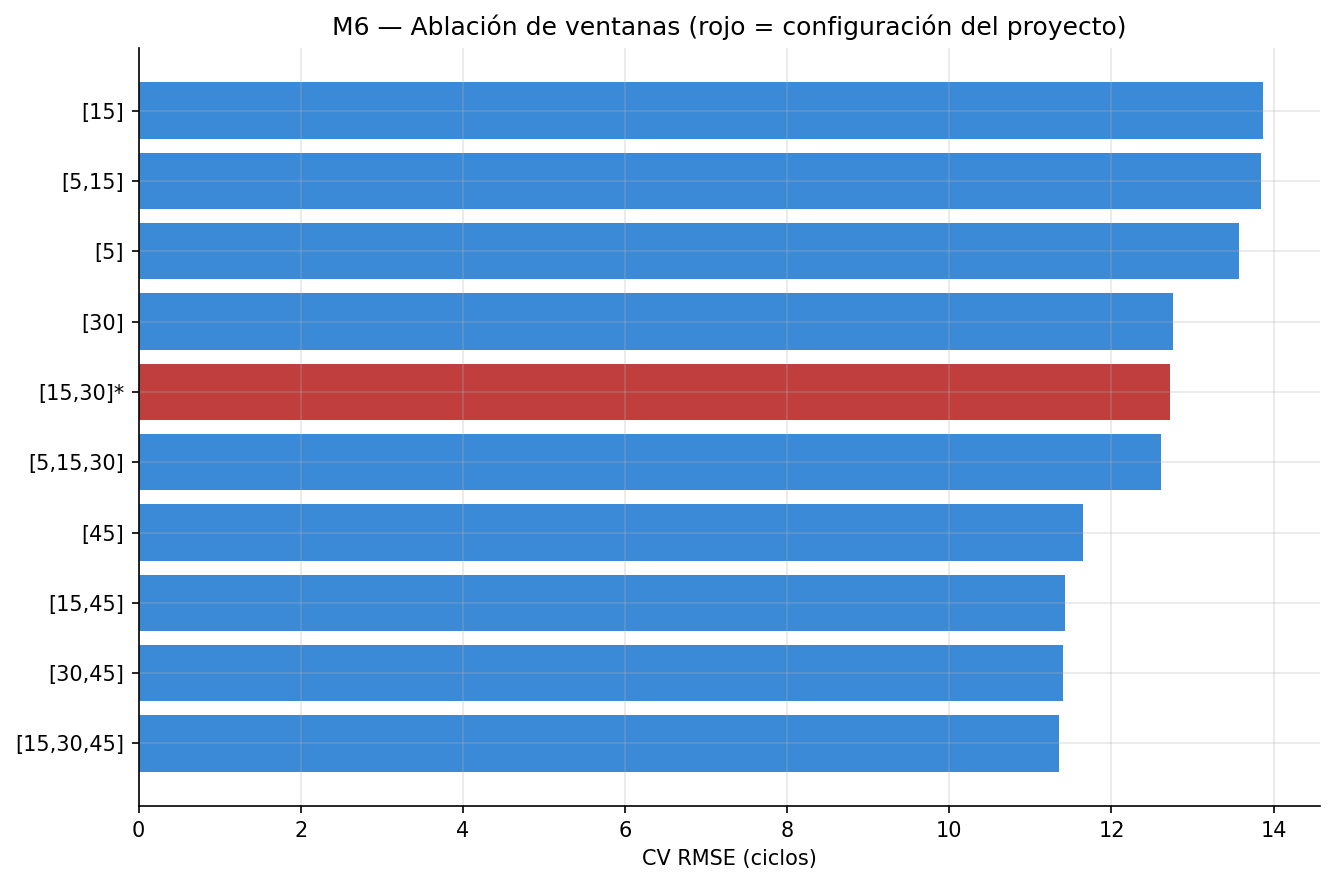

,Ventanas,n_feats,CV_RMSE,CV_std,Test_RMSE
9,"[15,30,45]",154,11.349517,0.415684,12.533874
7,"[30,45]",112,11.397118,0.432954,12.402012
6,"[15,45]",112,11.428236,0.366616,12.541010
3,[45],70,11.651251,0.437597,12.660565
8,"[5,15,30]",154,12.605355,0.861771,11.371479
5,"[15,30]*",112,12.727523,0.871274,11.961341
2,[30],70,12.755124,0.802825,12.270645
0,[5],70,13.574057,1.388865,13.607696
4,"[5,15]",112,13.844518,1.381152,13.983186
1,[15],70,13.872307,1.432431,13.838957


In [16]:
m6 = f7.run_m6(f0.INFORMATIVE_EXPECTED)
display(Image(filename=f"{f0.OUTPUT_DIR}/f7_06_ablacion_ventanas.png"))
m6


**Mismo patrón de sesgo-varianza que en Fase 2.** La
configuración `[15,30,45]` gana en CV (11.35) pero pierde en test
(12.53) frente a `[15,30]*` (CV=12.73, test=11.96) — igual que en Fase
2, más ventanas/features mejora el ajuste de validación cruzada sin
que eso se traduzca en mejor generalización. Confirma, con un modelo y
una semilla distintos a los del README original, la misma conclusión
de diseño: `[15,30]` es un compromiso razonable, no solo la opción más
simple.


## Resumen Fase 7

| Mejora | Resultado (este run) | ¿Coincide con README? |
|---|---|---|
| M1 | XGB vs LGB: p=0.021 (sig.); XGB vs RF: p=0.567 (no sig.) | Parcialmente — mismo patrón XGB-LGB, XGB-RF cambia porque RF ahora es mejor modelo |
| M2 | RMSE censurado (12.44) > no censurado (11.17) | Sí, mismo patrón cualitativo |
| M3 | Mejor PHM: RandomForest | No — README decía XGBoost (coherente con Fase 4) |
| M4 | Quitar s14 EMPEORA el test RMSE (+0.6) | **No — invierte la conclusión del README** |
| M5 | BP pooled p≈0, BP por-motor p=0.0022 (ambos sig.) | Sí, y más riguroso (test correcto + chequeo de pseudo-replicación) |
| M6 | `[15,30]` buen compromiso CV/test, mismo patrón que Fase 2 | Sí |

Todas las discrepancias con el README son trazables a un único origen
ya documentado: el modelo de Fase 4 reentrenado en este entorno difiere
del original (probable deriva de versión de librerías). Las
correcciones metodológicas (M1 relabeling, M5 Breusch-Pagan genuino +
pseudo-replicación) son independientes de esa discrepancia y aplicarían
igual sobre el modelo original.
